# 💊 증강 전략 비교 실험

각 증강 전략을 **독립적**으로 fold0에 적용해 학습 후 mAP를 비교합니다.

| 단계 | 내용 |
|------|------|
| 0 | 환경 설정 |
| 1 | augment_dataset.py 저장 |
| 2 | 전략별 증강 실험 루프 |
| 3 | 결과 비교 |


## 0. 환경 설정


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q 'rfdetr[train,loggers]' albumentations opencv-python-headless


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [2]:
import os, torch

SHARED_ID   = '1SlNpnNKD7cPbwLJH0A9-WUcx1Fhbzfrd'
SHARED_DIR  = f'/content/drive/.shortcut-targets-by-id/{SHARED_ID}/ai12-level1-project'
DATASET_DIR = '/content/dataset'
MY_OUTPUT   = '/content/drive/MyDrive/pill_detection_outputs'
os.makedirs(MY_OUTPUT, exist_ok=True)

# GPU 확인
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {vram:.1f} GB')
    BATCH_SIZE = 8 if vram >= 16 else 4
    GRAD_ACCUM = 2 if vram >= 16 else 4
else:
    raise RuntimeError('GPU 필요')

# 데이터 복원 (이미 있으면 스킵)
if not os.path.exists(DATASET_DIR) or not os.listdir(DATASET_DIR):
    import shutil
    ZIP = os.path.join(SHARED_DIR, 'dataset_5fold.zip')
    shutil.copy(ZIP, '/content/dataset_5fold.zip')
    os.system('unzip -qo /content/dataset_5fold.zip -d /content/dataset')
    os.remove('/content/dataset_5fold.zip')
    print('✅ 데이터 복원 완료')
else:
    print('✅ 데이터 이미 존재')

print(f'BATCH={BATCH_SIZE} ACCUM={GRAD_ACCUM} (유효배치={BATCH_SIZE*GRAD_ACCUM})')


GPU : NVIDIA L4
VRAM: 23.7 GB
✅ 데이터 복원 완료
BATCH=8 ACCUM=2 (유효배치=16)


## 1. `augment_dataset.py` 저장


In [3]:
import sys
sys.path.insert(0, '/content')
from augment_dataset import augment_fold, list_strategies, STRATEGIES
list_strategies()

사용 가능한 증강 전략:
  baseline             증강 없음 (대조군)
  rotate               회전 ±180° (알약 360° 대칭 특성)
  flip                 좌우/상하 반전
  color                밝기·대비·채도·색조·CLAHE
  blur                 가우시안/모션/미디안/Defocus 블러
  noise                가우시안/ISO/곱셈 노이즈
  distortion           탄성/격자/광학 왜곡
  weather              비/안개/그림자/태양빛
  copy_paste           알약 객체 Copy-Paste
  combined_light       회전+반전+색상+노이즈 경량 조합
  combined_heavy       회전+반전+색상+블러+노이즈 강한 조합


/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
/content/augment_dataset.py:120: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.2, shift_limit=0.05, p=1.0),
/content/augment_dataset.py:125: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=12,
/content/augment_dataset.py:128: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.35, alpha_coef=0.08, p=1.0),
/content/augment_dataset.py:129: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(shadow_roi=(0,0,1,1), num_shadows_lower=1,
/content/augment_dataset.py:131: UserWarning: Argu

## 2. 전략별 증강 + 학습 실험

> fold0만 사용, 50 epoch (early stopping 포함)으로 빠르게 비교합니다.

**실험할 전략 선택** — `RUN_STRATEGIES` 에서 원하는 것만 켜세요.


In [4]:
# ── 실험 설정 ────────────────────────────────────────────────
FOLD_IDX   = 0       # 비교용 fold (0 고정)
EPOCHS     = 50      # 비교용 epoch (빠른 비교)
AUG_FACTOR = 2       # 이미지당 증강본 수 (원본 + 2배)
EXP_PREFIX = 'aug_exp_v1'

# 실험할 전략 (True = 실행, False = 스킵)
RUN_STRATEGIES = {
    'baseline':       True,
    'rotate':         True,
    'flip':           True,
    'color':          True,
    'blur':           True,
    'noise':          True,
    'distortion':     True,
    'weather':        True,
    'copy_paste':     True,
    'combined_light': True,
    'combined_heavy': True,
}

# 하이퍼파라미터 (고정)
LR, LR_ENCODER, WEIGHT_DECAY        = 1e-4, 1.5e-4, 1e-4
LR_SCHEDULER, WARMUP_EPOCHS, LR_MIN = 'cosine', 0.0, 0.0
ES_PATIENCE, ES_MIN_DELTA           = 7, 0.001

active = [s for s, v in RUN_STRATEGIES.items() if v]
print(f'실험 전략 {len(active)}개: {active}')
print(f'fold={FOLD_IDX} | epochs={EPOCHS} | aug_factor={AUG_FACTOR}')


실험 전략 11개: ['baseline', 'rotate', 'flip', 'color', 'blur', 'noise', 'distortion', 'weather', 'copy_paste', 'combined_light', 'combined_heavy']
fold=0 | epochs=50 | aug_factor=2


In [12]:
# augment_dataset.py 의 함수 시그니처 수정
with open('/content/augment_dataset.py', 'r', encoding='utf-8') as f:
    src = f.read()

# src_anns 파라미터 제거 (함수 내부에서 실제로 안 쓰임)
src = src.replace(
    'def _copy_paste_augment(image, bboxes_coco, category_ids,\n'
    '                         src_images, src_anns,\n'
    '                         n_paste_range=(1, 3), p=0.8):',
    'def _copy_paste_augment(image, bboxes_coco, category_ids,\n'
    '                         src_images,\n'
    '                         n_paste_range=(1, 3), p=0.8):'
)

with open('/content/augment_dataset.py', 'w', encoding='utf-8') as f:
    f.write(src)

print('✅ 수정 완료')

# 모듈 리로드
import importlib, augment_dataset
importlib.reload(augment_dataset)
from augment_dataset import augment_fold, STRATEGIES
print('✅ 리로드 완료')

✅ 수정 완료
✅ 리로드 완료


In [13]:
# copy_paste만 재실행
active = ['copy_paste']

In [14]:
import time, shutil, importlib
from rfdetr import RFDETRMedium
import sys; sys.path.insert(0, '/content')
import augment_dataset; importlib.reload(augment_dataset)
from augment_dataset import augment_fold

aug_results = []

for strategy in active:
    print(f"\n{'='*60}\n전략: {strategy}\n{'='*60}")

    # ── 1. 증강 데이터셋 생성 ────────────────────────────────
    aug_dir = f'/content/aug_{strategy}'
    ckpt_key = f'{EXP_PREFIX}_{strategy}_fold{FOLD_IDX}'
    dst_ckpt = os.path.join(MY_OUTPUT, f'{ckpt_key}_best.pth')

    if os.path.exists(dst_ckpt):
        print(f'✅ 이미 완료 → 스킵 ({dst_ckpt})')
        aug_results.append({'strategy': strategy, 'status': 'skipped', 'ckpt': dst_ckpt})
        continue

    t_aug = time.time()
    try:
        augment_fold(strategy, fold_idx=FOLD_IDX,
                     dataset_dir=DATASET_DIR,
                     out_dir=aug_dir,
                     aug_factor=AUG_FACTOR)
        aug_sec = round(time.time()-t_aug, 1)
        print(f'  증강 완료: {aug_sec}s')
    except Exception as e:
        print(f'❌ 증강 실패: {e}')
        aug_results.append({'strategy': strategy, 'status': f'aug_error: {e}'})
        continue

    # ── 2. 학습 ───────────────────────────────────────────────
    out_dir = f'/content/outputs/{ckpt_key}'
    os.makedirs(out_dir, exist_ok=True)

    t_train = time.time()
    try:
        model = RFDETRMedium()
        model.train(
            dataset_dir              = f'{aug_dir}/fold{FOLD_IDX}',
            output_dir               = out_dir,
            epochs                   = EPOCHS,
            batch_size               = BATCH_SIZE,
            grad_accum_steps         = GRAD_ACCUM,
            lr                       = LR,
            lr_encoder               = LR_ENCODER,
            weight_decay             = WEIGHT_DECAY,
            lr_scheduler             = LR_SCHEDULER,
            warmup_epochs            = WARMUP_EPOCHS,
            lr_min_factor            = LR_MIN,
            early_stopping           = True,
            early_stopping_patience  = ES_PATIENCE,
            early_stopping_min_delta = ES_MIN_DELTA,
            tensorboard              = True,
        )
        train_sec = round(time.time()-t_train, 1)

        # best 체크포인트 내 Drive 저장
        src_ckpt = os.path.join(out_dir, 'checkpoint_best_total.pth')
        if os.path.exists(src_ckpt):
            shutil.copy(src_ckpt, dst_ckpt)
            print(f'✅ 저장 → {dst_ckpt}')
            aug_results.append({
                'strategy': strategy, 'status': 'done',
                'aug_sec': aug_sec, 'train_sec': train_sec,
                'ckpt': dst_ckpt,
            })
        else:
            aug_results.append({'strategy': strategy, 'status': 'no_ckpt'})

    except Exception as e:
        print(f'❌ 학습 실패: {e}')
        aug_results.append({'strategy': strategy, 'status': f'train_error: {str(e)[:60]}'})

    finally:
        try: del model
        except: pass
        torch.cuda.empty_cache()

    # 증강 데이터 정리 (디스크 절약)
    if os.path.exists(aug_dir):
        shutil.rmtree(aug_dir)
        print(f'  증강 디렉토리 정리: {aug_dir}')

print(f"\n{'='*60}\n✅ 전체 실험 완료\n{'='*60}")



전략: copy_paste

[augment_fold] strategy=copy_paste | fold=0 | aug_factor=2
  /content/dataset/fold0 → /content/aug_copy_paste/fold0
  valid: 50장 복사 완료
  Copy-Paste: 소스 풀 로딩 중...
  소스 풀: 182장
  ✅ 완료: 원본 182장 + 증강 364장 = 총 546장
  총 박스: 2466개
  증강 완료: 37.3s
[2026-07-02 04:48:43] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-07-02 04:48:43] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 04:48:43] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-02 04:48:44] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-07-02 04:48:45] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-medium.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-07-02 04:48:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 04:48:45] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-02 04:48:47] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


...

[2026-07-02 04:56:19] [INFO] rf-detr - Best EMA mAP improved to 0.8516 (epoch 10)


INFO:pytorch_lightning.callbacks.early_stopping:Metric __rfdetr_effective_map__ improved by 0.015 >= min_delta = 0.001. New best score: 0.867


[2026-07-02 04:57:01] [INFO] rf-detr - Best EMA mAP improved to 0.8665 (epoch 11)
[2026-07-02 04:57:41] [INFO] rf-detr - Best regular checkpoint saved to /content/outputs/aug_exp_v1_copy_paste_fold0/checkpoint_best_regular.pth (epoch 12, monitor=val/mAP_50_95, value=0.845489)


INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric __rfdetr_effective_map__ did not improve in the last 7 records. Best score: 0.867. Signaling Trainer to stop.


[2026-07-02 05:01:48] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.8455, ema=0.8665)
✅ 저장 → /content/drive/MyDrive/pill_detection_outputs/aug_exp_v1_copy_paste_fold0_best.pth
  증강 디렉토리 정리: /content/aug_copy_paste

✅ 전체 실험 완료


## 3. 결과 비교


In [15]:
import pandas as pd, glob, json

# ── 학습 결과 테이블 ──────────────────────────────────────────
df = pd.DataFrame(aug_results)
display(df)


,strategy,status,aug_sec,train_sec,ckpt
0,copy_paste,done,37.3,786.1,/content/drive/MyDrive/pill_detection_outputs/...


In [16]:
import os, glob

# 내 Drive에서 완료된 전략 확인
MY_OUTPUT = '/content/drive/MyDrive/pill_detection_outputs'
ckpts = glob.glob(os.path.join(MY_OUTPUT, f'{EXP_PREFIX}_*_fold0_best.pth'))

print('완료된 전략:')
for c in sorted(ckpts):
    name = os.path.basename(c).replace(f'{EXP_PREFIX}_','').replace(f'_fold0_best.pth','')
    size = os.path.getsize(c)/1e6
    print(f'  ✅ {name}  ({size:.0f} MB)')

print('\n미완료 전략 → 재실행 필요')

완료된 전략:
  ✅ baseline  (134 MB)
  ✅ blur  (134 MB)
  ✅ color  (134 MB)
  ✅ combined_heavy  (134 MB)
  ✅ combined_light  (134 MB)
  ✅ copy_paste  (134 MB)
  ✅ distortion  (134 MB)
  ✅ flip  (134 MB)
  ✅ noise  (134 MB)
  ✅ rotate  (134 MB)
  ✅ weather  (134 MB)

미완료 전략 → 재실행 필요


In [18]:
from rfdetr import RFDETRMedium
model = RFDETRMedium()
print([m for m in dir(model) if not m.startswith('_')])

[2026-07-02 05:03:38] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-07-02 05:03:38] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 05:03:38] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-02 05:03:39] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-07-02 05:03:40] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-medium.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


['callbacks', 'class_names', 'deploy_to_roboflow', 'export', 'export_for_roboflow', 'from_checkpoint', 'get_model', 'get_model_config', 'get_train_config', 'is_optimized_inplace', 'maybe_download_pretrain_weights', 'means', 'model', 'model_config', 'optimize_for_inference', 'predict', 'remove_optimized_model', 'size', 'stds', 'train']


In [21]:
import os, glob, torch, json
from rfdetr import RFDETRMedium
from PIL import Image
from torchmetrics.detection import MeanAveragePrecision
from collections import defaultdict

MY_OUTPUT   = '/content/drive/MyDrive/pill_detection_outputs'
DATASET_DIR = '/content/dataset'
EXP_PREFIX  = 'aug_exp_v1'
FOLD_IDX    = 0

# valid 어노테이션 로드
ann_path = f'{DATASET_DIR}/fold{FOLD_IDX}/valid/_annotations.coco.json'
with open(ann_path) as f:
    coco = json.load(f)

id2img  = {img['id']: img for img in coco['images']}
ann_by  = defaultdict(list)
for ann in coco['annotations']:
    ann_by[ann['image_id']].append(ann)

val_dir = f'{DATASET_DIR}/fold{FOLD_IDX}/valid'

def evaluate_ckpt(ckpt_path, threshold=0.3):
    model  = RFDETRMedium(pretrain_weights=ckpt_path)
    metric = MeanAveragePrecision(iou_type='bbox')

    for img_info in coco['images']:
        img_path = os.path.join(val_dir, img_info['file_name'])
        if not os.path.exists(img_path): continue

        img  = Image.open(img_path).convert('RGB')
        dets = model.predict(img, threshold=threshold)

        # GT
        gt_boxes = []
        gt_labels = []
        for ann in ann_by[img_info['id']]:
            x,y,w,h = ann['bbox']
            gt_boxes.append([x, y, x+w, y+h])
            gt_labels.append(ann['category_id'])

        preds = [{'boxes':  torch.tensor(dets.xyxy, dtype=torch.float32),
                  'scores': torch.tensor(dets.confidence, dtype=torch.float32),
                  'labels': torch.tensor(dets.class_id, dtype=torch.int64)}]
        targets = [{'boxes':  torch.tensor(gt_boxes,  dtype=torch.float32),
                    'labels': torch.tensor(gt_labels, dtype=torch.int64)}]
        metric.update(preds, targets)

    result = metric.compute()
    del model; torch.cuda.empty_cache()
    return result['map'].item()

# ── 전체 평가 ────────────────────────────────────────────────
map_results = []
ckpts = sorted(glob.glob(os.path.join(MY_OUTPUT, f'{EXP_PREFIX}_*_fold{FOLD_IDX}_best.pth')))

for ckpt in ckpts:
    strategy = os.path.basename(ckpt)\
        .replace(f'{EXP_PREFIX}_','').replace(f'_fold{FOLD_IDX}_best.pth','')
    print(f'평가 중: {strategy} ...', end=' ')
    try:
        mAP = evaluate_ckpt(ckpt)
        print(f'mAP={mAP:.4f}')
        map_results.append({'strategy': strategy, 'mAP': round(mAP, 4)})
    except Exception as e:
        print(f'❌ {e}')
        map_results.append({'strategy': strategy, 'mAP': None})

import pandas as pd
df = pd.DataFrame(map_results).sort_values('mAP', ascending=False).reset_index(drop=True)
display(df.style.highlight_max(subset=['mAP'], color='#d4edda'))

[2026-07-02 05:09:35] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 05:09:35] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


평가 중: baseline ... 

[2026-07-02 05:09:36] [WARNING] rf-detr - Checkpoint has 57 classes but model is configured for 90. Using checkpoint class count (57). Pass num_classes=57 to suppress this warning.
[2026-07-02 05:09:36] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-07-02 05:09:36] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).
[2026-07-02 05:09:40] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 05:09:40] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.

mAP=0.8440
평가 중: blur ... 

[2026-07-02 05:09:40] [WARNING] rf-detr - Checkpoint has 57 classes but model is configured for 90. Using checkpoint class count (57). Pass num_classes=57 to suppress this warning.
[2026-07-02 05:09:40] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-07-02 05:09:40] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).
[2026-07-02 05:09:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 05:09:44] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.

...

[2026-07-02 05:10:16] [WARNING] rf-detr - Checkpoint has 57 classes but model is configured for 90. Using checkpoint class count (57). Pass num_classes=57 to suppress this warning.
[2026-07-02 05:10:16] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-07-02 05:10:16] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).
[2026-07-02 05:10:20] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-02 05:10:20] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.

mAP=0.8331
평가 중: weather ... 

[2026-07-02 05:10:21] [WARNING] rf-detr - Checkpoint has 57 classes but model is configured for 90. Using checkpoint class count (57). Pass num_classes=57 to suppress this warning.
[2026-07-02 05:10:21] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-07-02 05:10:21] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).


mAP=0.8409


,strategy,mAP
0,baseline,0.844000
1,weather,0.840900
2,copy_paste,0.837300
3,combined_heavy,0.835800
4,color,0.833700
5,rotate,0.833100
6,distortion,0.832800
7,blur,0.832700
8,flip,0.831100
9,noise,0.828400


In [7]:
# ── TensorBoard 로그에서 best mAP 추출 ──────────────────────
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    map_results = []

    for strategy in active:
        ckpt_key = f'{EXP_PREFIX}_{strategy}_fold{FOLD_IDX}'
        log_dir  = f'/content/outputs/{ckpt_key}'
        logs = glob.glob(f'{log_dir}/**/events.out.*', recursive=True)
        if not logs:
            # 내 Drive에서 로그 없음 → 스킵
            map_results.append({'strategy': strategy, 'best_mAP': None, 'best_epoch': None})
            continue
        ea = EventAccumulator(logs[0]); ea.Reload()
        tags = ea.Tags().get('scalars', [])

        # mAP 태그 찾기
        map_tag = next((t for t in tags if 'map' in t.lower() and 'val' in t.lower()), None)
        if map_tag is None:
            map_tag = next((t for t in tags if 'map' in t.lower()), None)

        if map_tag:
            scalars = ea.Scalars(map_tag)
            best_val   = max(s.value for s in scalars)
            best_epoch = max(range(len(scalars)), key=lambda i: scalars[i].value) + 1
            map_results.append({'strategy': strategy, 'best_mAP': round(best_val,4), 'best_epoch': best_epoch})
        else:
            map_results.append({'strategy': strategy, 'best_mAP': None, 'best_epoch': None})

    mdf = pd.DataFrame(map_results).sort_values('best_mAP', ascending=False).reset_index(drop=True)
    print('\n📊 증강 전략별 best mAP (val, fold0):')
    display(mdf.style.highlight_max(subset=['best_mAP'], color='#d4edda'))

except Exception as e:
    print(f'TensorBoard 파싱 오류: {e}\n수동으로 확인하거나 학습 로그를 참조하세요')



📊 증강 전략별 best mAP (val, fold0):


,strategy,best_mAP,best_epoch
0,color,0.853700,13.000000
1,blur,0.853100,17.000000
2,baseline,0.845300,17.000000
3,weather,0.842900,11.000000
4,combined_light,0.840800,12.000000
5,combined_heavy,0.840600,10.000000
6,distortion,0.839400,5.000000
7,noise,0.835400,13.000000
8,rotate,0.834600,15.000000
9,flip,0.832900,8.000000


✅ 한글 폰트 설정 완료


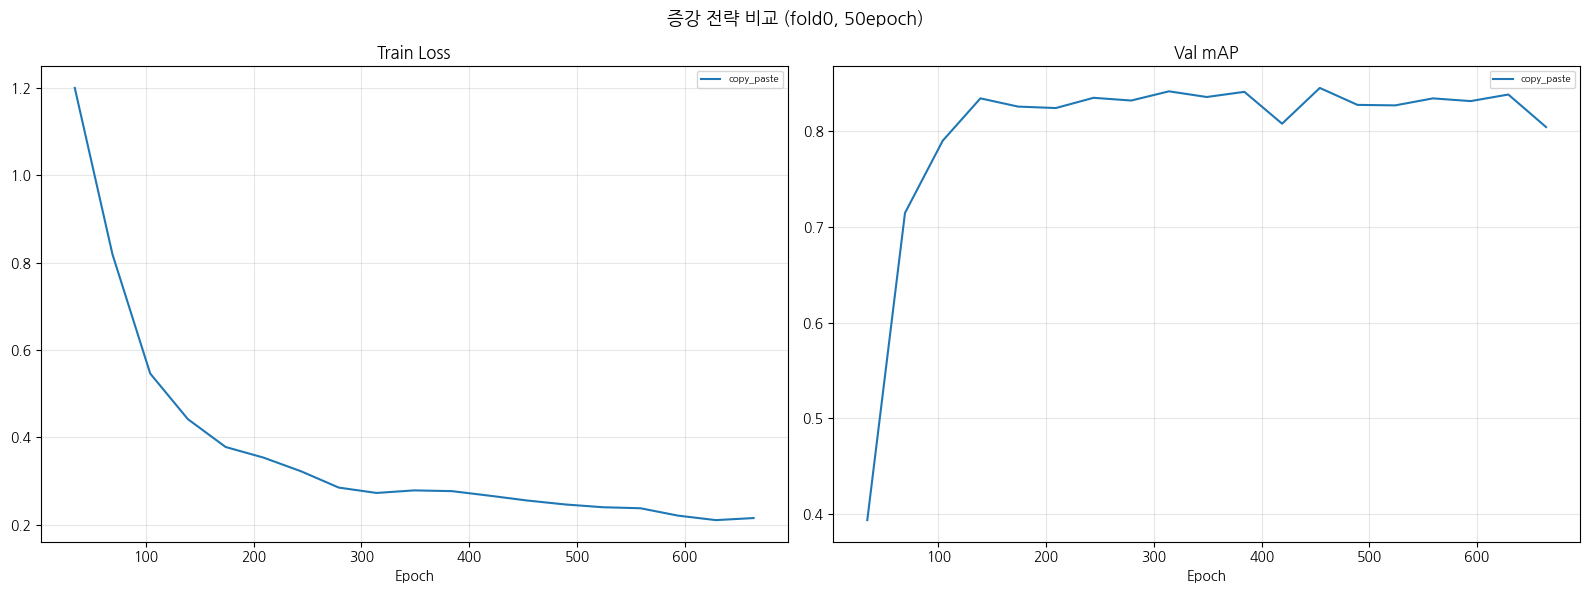

aug_comparison.png 저장됨


In [20]:
# ── 시각화 ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import subprocess
import matplotlib.font_manager as fm
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)
fm.fontManager.__init__()
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('✅ 한글 폰트 설정 완료')

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = plt.cm.tab20.colors

    for ci, strategy in enumerate(active):
        ckpt_key = f'{EXP_PREFIX}_{strategy}_fold{FOLD_IDX}'
        logs = glob.glob(f'/content/outputs/{ckpt_key}/**/events.out.*', recursive=True)
        if not logs: continue
        ea = EventAccumulator(logs[0]); ea.Reload()
        tags = ea.Tags().get('scalars', [])
        color = colors[ci % len(colors)]

        # Loss
        loss_tag = next((t for t in tags if 'loss' in t.lower() and 'train' in t.lower()), None)
        if loss_tag:
            sc = ea.Scalars(loss_tag)
            axes[0].plot([s.step for s in sc], [s.value for s in sc],
                        label=strategy, color=color)

        # mAP
        map_tag = next((t for t in tags if 'map' in t.lower()), None)
        if map_tag:
            sc = ea.Scalars(map_tag)
            axes[1].plot([s.step for s in sc], [s.value for s in sc],
                        label=strategy, color=color)

    axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)
    axes[1].set_title('Val mAP');    axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=7, ncol=2); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'증강 전략 비교 (fold{FOLD_IDX}, {EPOCHS}epoch)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(MY_OUTPUT, 'aug_comparison.png'), dpi=100)
    plt.show()
    print('aug_comparison.png 저장됨')

except Exception as e:
    print(f'시각화 오류: {e}')
